# Προσομοιώσεις Πλεγμάτων Επιταχυντών με Python και Xsuite
# Μάθημα 3ο: Δυναμική ενός σωματιδίου σε περιοδικά συστήματα (δακτύλιοι)
#### Φυσική των Επιταχυντών
#### Μεταπτυχιακό Υποατομικής Φυσικής, 2o έτος
#### Τμήμα Φυσικής / Αριστοτέλειο Πανεπιστήμιο Θεσσαλονίκης
#### Εαρινό εξάμηνο 2025 

*T. Prebibaj, F. Antoniou, F. Asvesta, Y. Papaphilippou*

In [1]:
# Import custom tracking functions and useful libraries
from tracking_library import *
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

---
## 📌 Εγκάρσια δυναμική σε δακτύλιο

- Ένας **δακτύλιος επιταχυντή** μπορεί να θεωρηθεί ως μια περιοδική γραμμή δέσμης: αποτελείται από έναν αριθμό κελιών/στοιχείων, με τα οποία τα σωματίδια αλληλεπιδρούν επαναληπτικά, "turn-by-turn". Στους πραγματικούς επιταχυντές, τα σωματίδια μπορούν να εκτελέσουν χιλιάδες, εκατομμύρια ή δεκάδες εκατομμύρια περιστροφές. Επομένως, η σταθερότητα της κίνησης των σωματιδίων στο **πλέγμα του επιταχυντή** (που είναι η ακολουθία των στοιχείων του επιταχυντή) είναι αναγκαία.

- Ο χώρος φάσης παρέχει χρήσιμες πληροφορίες για τη δυναμική της κίνησης των σωματιδίων.


### 📝 Άσκηση 11: φασικός χώρος σε σταθερό δακτύλιο (phase space in a stable ring)

- Μοντελοποιήστε έναν σταθερό δακτύλιο που αποτελείται από 16 κελιά FODO και έχει συνολικό μήκος 160 μέτρα. Κάθε κελί FODO πρέπει να περιέχει έναν εστιακό και έναν αποεστιακό τετραπολικό μαγνήτη. Επιλέξτε $f = 0.8L$, όπου *L* είναι το μήκος καθενός από τα δύο ίσα ευθύγραμμα διαστήματα κάθε κελιού.

- Παρακολουθήστε την κίνηση ενός σωματιδίου με αρχικές συνθήκες $x_0 = 0$ και $x'_0 = 1$ mrad για 100 στροφές. Σχεδιάστε την τροχιά του σωματιδίου "turn-by-turn".

- Σχεδιάστε την τροχιά του σωματιδίου στον χώρο φάσης στα σημεία $s = 0$ και $s = 55$ m για τις 100 στροφές.


In [2]:
# Modelling the ring
C = 160 # circumference in meters
Lcell = C/16 # length of one FODO cell in meters
L = Lcell/2 # length of one drift in the fodo cell
f = 0.8*L 
basic_cell = 5*D(L/10) + Q(f) + 10*D(L/10) + Q(-f) + 5*D(L/10)
myRing = basic_cell*16

# Initial particle coordinates
X_0 = np.array([[0],
                [1e-3]])

# Tracking the particle for 100 turns
nturns = 100
transported_particle_turnbyturn = {}
transported_particle_turnbyturn[0] = transportParticles(X_0, myRing, s_0=0)
for turn in range(1,nturns+1):
    X_1 = np.array([transported_particle_turnbyturn[turn-1]['x'][-1],
                    transported_particle_turnbyturn[turn-1]['xp'][-1]])
    transported_particle_turnbyturn[turn] = transportParticles(X_1, myRing, s_0=0)

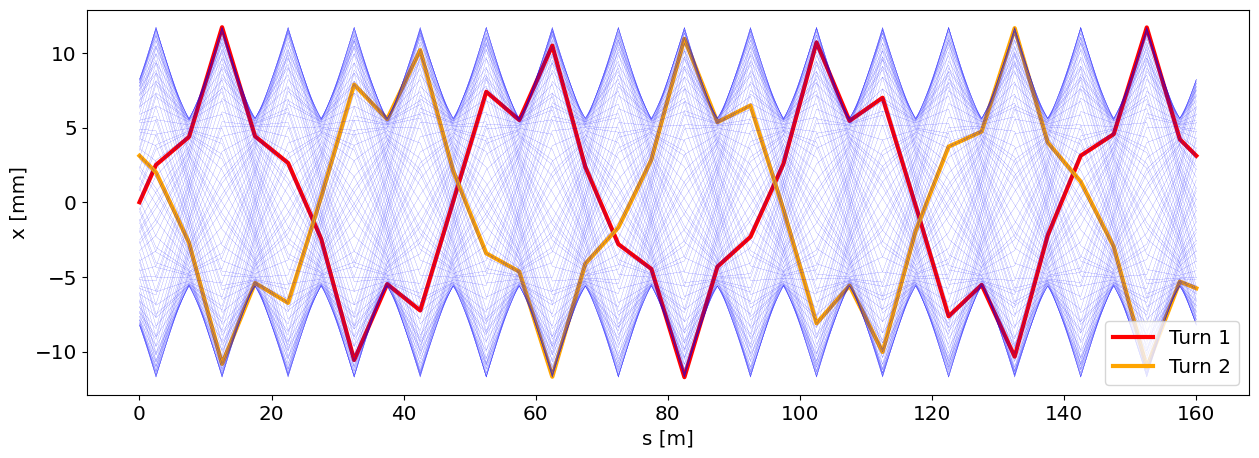

In [3]:
plt.plot(transported_particle_turnbyturn[0]['s'], transported_particle_turnbyturn[0]['x']*1e3, c='red', ls='-', linewidth=3, label='Turn 1')
plt.plot(transported_particle_turnbyturn[1]['s'], transported_particle_turnbyturn[1]['x']*1e3, c='orange', ls='-', linewidth=3, label='Turn 2')
for i in range(nturns):
    plt.plot(transported_particle_turnbyturn[i]['s'], transported_particle_turnbyturn[i]['x']*1e3, c='blue', ls='-', linewidth=0.1)
plt.xlabel('s [m]')
plt.ylabel('x [mm]')
plt.legend(loc=0)

Text(0.5, 1.0, 'Phase space at s=55 m')

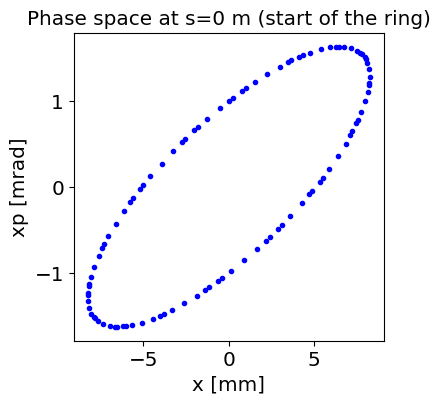

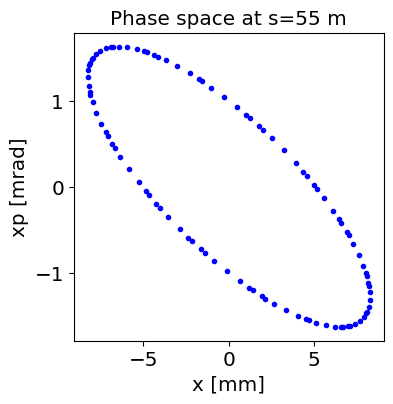

In [4]:
# Phase space at s=0
index_of_s = np.where(transported_particle_turnbyturn[0]['s'] == 0.0)[0][0]
plt.figure(figsize=(4,4))
for i in range(nturns):
    plt.plot(transported_particle_turnbyturn[i]['x'][index_of_s]*1e3, 
             transported_particle_turnbyturn[i]['xp'][index_of_s]*1e3, 
             '.', c='blue')
plt.xlabel('x [mm]')
plt.ylabel('xp [mrad]')
plt.title('Phase space at s=0 m (start of the ring)')

# Phase space at s=55
index_of_s = np.where(transported_particle_turnbyturn[0]['s'] == 55.0)[0][0]
plt.figure(figsize=(4,4))
for i in range(nturns):
    plt.plot(transported_particle_turnbyturn[i]['x'][index_of_s]*1e3, 
             transported_particle_turnbyturn[i]['xp'][index_of_s]*1e3, 
             '.', c='blue')
plt.xlabel('x [mm]')
plt.ylabel('xp [mrad]')
plt.title('Phase space at s=55 m')

- Το σωματίδιο εκτελεί, σε κάθε στροφή ("turn-by-turn"), έναν ορισμένο αριθμό ταλαντώσεων βήτατρον. Ο αριθμός αυτός είναι γνωστός ως **tune $Q_x$** (*M2-δ35*).

- Στον χώρο φάσης, το σωματίδιο παραμένει, turn-by-turn, πάνω σε μια έλλειψη (*M2-δ30*). Αυτή η έλλειψη παραμετροποιείται ως:

    \begin{equation}
    \gamma x^2 + 2\alpha x x' + \beta x'^2 = \epsilon
    \end{equation}

    όπου τα $(\alpha, \beta, \gamma)$ είναι οι **παράμετροι Twiss** και το $\epsilon$ η **single particle emittance ή Courant-Snyder invariant**. Η έλλειψη στον χώρο φάσης αναπαριστά τις βητατρονικές ταλαντώσεις γύρω από το σταθερό σημείο $(x, x') = (0, 0)$. Θυμηθείτε ότι η παραμετροποίηση της ταλάντωσης βήτατρον είναι (*M2-δ29*):  
    $x(s) = \sqrt{\epsilon \beta(s)} \cos(\psi(s) + \psi_0)$

- Το εμβαδόν της έλλειψης είναι $A = 2\pi \cdot \epsilon$. Μπορεί να δειχθεί ότι το $\epsilon$ ενός σωματιδίου είναι αναλλοίωτη ποσότητα (αναλλοίωτο Courant–Snyder – *ΜΙΙ-δ30*).

- Οι παράμετροι Twiss (που καθορίζουν τον προσανατολισμό της έλλειψης) εξαρτώνται από το *s*: εξαρτώνται δηλαδή από τη δομή του πλέγματος (διάταξη και ένταση των τετραπολικών).


- Ο ισοδύναμος πίνακας ($M_{\mathrm{eq.}}$) ενός δακτυλίου επιταχυντή είναι γνωστός ως **one-turn map** και παραμετροποιείται μέσω των παραμέτρων Twiss (*ΜΙΙ-δ34*) ως:

    \begin{equation}
    M = 
        \left[
        \begin{array}{cc}
        \cos(\mu) + \alpha_0 \sin(\mu)  & \beta_0 \sin(\mu)\\
        - \gamma_0 \sin(\mu) & \cos(\mu) - \alpha_0 \sin(\mu)
        \end{array}
        \right]
    \end{equation}

    όπου τα $\alpha_0$, $\beta_0$, $\gamma_0$ είναι οι αρχικές (και τελικές) τιμές των παραμέτρων Twiss και $\mu = 2\pi Q_x$ η "phase advance" της αντίστοιχης γραμμής δέσμης ή του δακτυλίου. Από αυτήν την έκφραση μπορεί να εξαχθεί η περιοδική λύση οποιασδήποτε γραμμής δέσμης, υπό την προϋπόθεση ότι αυτή υπάρχει.

    > **Σημείωση:** Εφόσον η ορίζουσα (determinant) της $M$ πρέπει να είναι ίσος με 1*, τότε μπορεί να δειχθεί ότι το ίχνος (trace) του πίνακα $M$ πρέπει να ικανοποιεί την $|\mathrm{Tr}(M)| \le 2$ ώστε να εξασφαλίζεται η ύπαρξη τέτοιας περιοδικής λύσης.
    
    > *Beam motion is governed by Hamiltonian mechanics, which preserves phase space are (Liouville's theorem). A map that preserves phase space volume is called symplectic. For a linear system, a matrix is symplectic if and only if its determinant is exactly one.


### 📝 Άσκηση 12: οπτική, ίχνος (trace) και single particle emittance σε δακτύλιο

- Υπολογίστε τις παραμέτρους Twiss στην αρχή του δακτυλίου για το πλέγμα της Άσκησης 11, καθώς και την betatron tune.  

- Υπολογίστε το ίχνος (trace) του one-turn-map και επαληθεύστε ότι είναι σταθερός.  

- Υπολογίστε την single particle emittance από τις παραμέτρους Twiss.   

In [8]:
# first, compute the equivalent "One-Turn-Map", and extract its matrix:
OTM = getEquivalentElement(myRing)
R = OTM[0]['matrix']

# all relevant Twiss parameters can be extracted from the matrix:
mu = np.arccos(0.5*(R[0,0]+R[1,1]))
if (R[0,1]<0): 
    mu = 2*np.pi-mu
Qx = mu/(2*np.pi)
betax = R[0,1]/np.sin(mu)
alphax = (0.5*(R[0,0]-R[1,1]))/np.sin(mu)
gammax = (1+alphax**2)/betax

print('Qx =', Qx)
print('beta_x =', betax)
print('alpha_x =', alphax)
print('gamma_x =', gammax)

Qx = 0.4384166625323947
beta_x = 8.246599920961968
alpha_x = -1.2810252304406948
gamma_x = 0.3202563076101743


> Σημείωση: Η οπτική (οι παράμετροι Twiss) είναι ανεξάρτητες από τις συντεταγμένες του σωματιδίου: είναι ιδιότητα του πλέγματος.

In [9]:
trace = np.trace(R)
print('Absolute value of trace of the One-Turn-Map:', abs(trace))

Absolute value of trace of the One-Turn-Map: 1.8521365701112402


In [10]:
x = X_0[0][0]
xp = X_0[1][0]
emittance = gammax*x**2 + 2*alphax*x*xp + betax*xp**2
print('Emittance of the particle [mm mrad]:', emittance*1e6)

Emittance of the particle [mm mrad]: 8.246599920961968


- Οι υπολογισμοί αυτοί είναι πολύ σημαντικοί, οπότε θα τους υλοποιήσουμε σε δύο συναρτήσεις με ονόματα `twiss` και `particle_emittance`:

In [11]:
def twiss(beamline):
    '''
    Computes and returns the closed solution (if it exist!) Tune (Q) and Twiss parameters 
    beta, alpha, gamma of the given beamline.
    '''

    # first, compute the equivalent "One-Turn-Map", and extract its matrix:
    OTM = getEquivalentElement(beamline)
    R = OTM[0]['matrix']
    
    # check that this matrix is stable:
    trace = np.trace(R)
    if np.abs(trace) > 2:
        raise ValueError('This beamline is not stable!')
    
    # all relevant Twiss parameters can be extrcted from the matrix:
    mu = np.arccos(0.5*(R[0,0]+R[1,1]))
    if (R[0,1]<0): 
        mu = 2*np.pi-mu
    Q = mu/(2*np.pi)
    beta = R[0,1]/np.sin(mu)
    alpha = (0.5*(R[0,0]-R[1,1]))/np.sin(mu)
    gamma = (1+alpha**2)/beta
    
    return Q, beta, alpha, gamma

def particle_emittance(x, xp, beta, alpha):
    '''Returns the single particle emittance for a given 
       x, xp particle coordinates and assumed beta and alpha parameters
    '''
    # compute gamma
    gamma = (alpha**2 + 1)/beta
    # compute and return the associated single particle emittance
    epsilon = gamma*x**2 + 2*alpha*x*xp + beta*xp**2
    return epsilon

### 📝 Άσκηση 13: σταθερότητα του δακτυλίου  

Στον δακτύλιο της Άσκησης 11, μεταβάλετε το $f$ από $1$ m (πολύ ισχυρή εστίαση) έως $15$ m (πολύ αδύναμη εστίαση) και βρείτε τις τιμές για τις οποίες ο δακτύλιος επιτρέπει σταθερές ταλαντώσεις, βάσει της συνθήκης $|Tr(R)| \le 2$.  
Χρησιμοποιήστε τη συνάρτηση `get_trace(beamline)` που ορίζεται παρακάτω.  
Αναπαραστήστε γραφικά την τιμή του Tr(R) για τις διαφορετικές αναλογίες $f/L$.

In [11]:
def get_trace(beamline):
    '''
    Computes and returns the trace of the equivalent "One-Turn-Map" of the given beamline.
    '''
    
    # first, compute the equivalent "One-Turn-Map", and extract its matrix:
    OTM = getEquivalentElement(beamline)
    R = OTM[0]['matrix']
    
    # check that this matrix is stable:
    trace = np.trace(R)

    return trace

(0.0, 3.0)

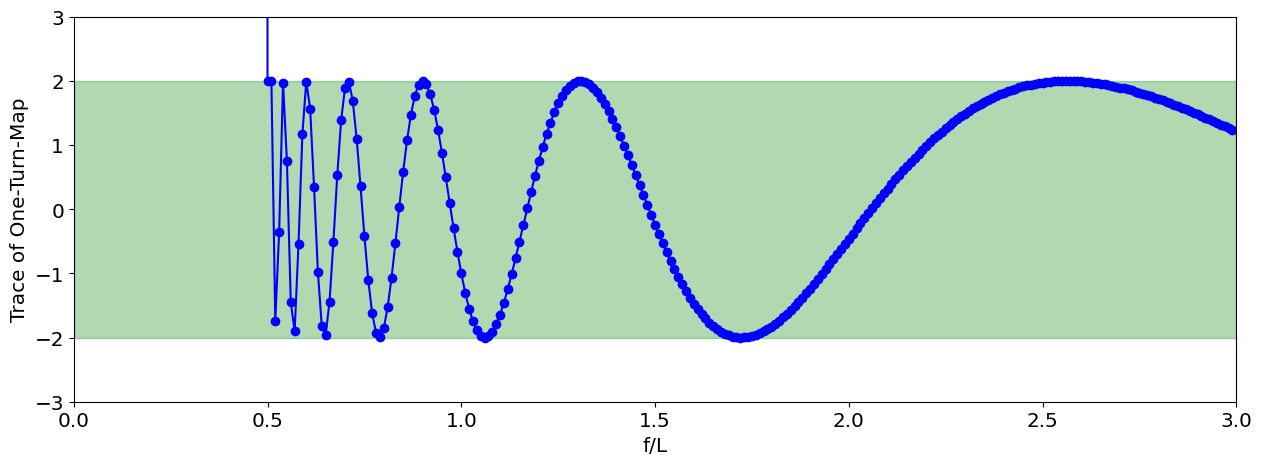

In [19]:
# We redefine the ring with the new f value
L = 5
frange = np.arange(1, 15, 0.05)
traces = []
for f in frange:
    FODO = 5*D(L/10) + Q(f) + 10*D(L/10) + Q(-f) + 5*D(L/10)
    myRing = FODO*16
    traces.append(get_trace(myRing))

plt.plot(frange/L, traces, 'o-', color='blue')
plt.xlabel('f/L')
plt.ylabel('Trace of One-Turn-Map')
plt.gca().fill_between([0,3], [-2,-2],  [2,2],color='green', alpha=0.3)
plt.ylim(-3,3)
plt.xlim(0,3)

- Μπορεί να αποδειχθεί (*διάλεξη ΙΙ διαφάνεια 36*), ότι οι συναρτήσεις Twiss από $s=s_1$ έως $s=s_2$ μπορούν να υπολογιστούν από:

    \begin{equation}
    \left(
    \begin{array}{c}
    \beta \\
    \alpha \\
    \gamma
    \end{array}
    \right)_{s_1} = 
    
    \left[
    \begin{array}{c}
    m_{11}^2 & -2m_{11}m_{12} & m_{12}^2\\
    -m_{11}m_{21} & m_{11}m_{22} + m_{12}m_{21} & -m_{22}m_{12}\\
    m_{21}^2 & -2m_{22}m_{21} & m_{22}^2\\
    \end{array}
    \right]
    
    \left(
    \begin{array}{c}
    \beta \\
    \alpha \\
    \gamma
    \end{array}
    \right)_{s_2},
    \end{equation}

    όπου:
    
    \begin{equation}
    M= \left[
    \begin{array}{c}
    m_{11}\quad m_{12}\\
    m_{21}\quad m_{22}
    \end{array}
    \right]
    \end{equation}

    είναι ο πίνακας μεταφοράς από $s=s_1$ σε $s=s_2$. Αυτό το ορίζουμε στη συνάρτηση `transport_optics` παρακάτω:

In [20]:
def transport_optics(beta1,alpha1,gamma1, M):
    '''
    This function computes the Twiss parameters of a beamline after 
    the transport of a beamline with Twiss parameters beta1, alpha1, gamma1
    through a matrix M.
    '''
    # compute the new Twiss parameters
    beta2 = M[0,0]**2*beta1 -2*M[0,0]*M[0,1]*alpha1 + M[0,1]**2*gamma1
    alpha2 = -M[0,0]*M[1,0]*beta1 + (M[0,0]*M[1,1] + M[0,1]*M[1,0])*alpha1 - M[0,1]*M[1,1]*gamma1
    gamma2 = M[1,0]**2*beta1 -2*M[1,0]*M[1,1]*alpha1 + M[1,1]**2*gamma1
    
    return beta2, alpha2, gamma2

### 📝 Άσκηση 14: μεταφορά των συναρτήσεων Twiss

Υπολογίστε και σχεδιάστε τις συναρτήσεις Twiss για τον δακτύλιο της Άσκησης 11 σε ολόκληρη την περιφέρεια του δακτυλίου.

In [21]:
# Modelling the ring of Exercise 11
C = 160 # circumference in meters
Lcell = C/16 # length of one FODO cell in meters
L = Lcell/2 # length of one drift in the fodo cell
f = 0.8*L # based on the stability diagram above
basic_cell = 5*D(L/10) + Q(f) + 10*D(L/10) + Q(-f) + 5*D(L/10)
myRing = basic_cell*16

# Optics at the beginning of the ring
Qx,beta0,alpha0,gamma0 = twiss(myRing)

betas = [beta0]
alphas = [alpha0]
gammas = [gamma0]
s = [0]
for i,element in enumerate(myRing):
    M = element['matrix']
    beta, alpha, gamma = transport_optics(betas[i], alphas[i], gammas[i], M)
    betas.append(beta)
    alphas.append(alpha)
    gammas.append(gamma)
    s.append(s[-1]+element['length'])

Text(0.5, 0, 's [m]')

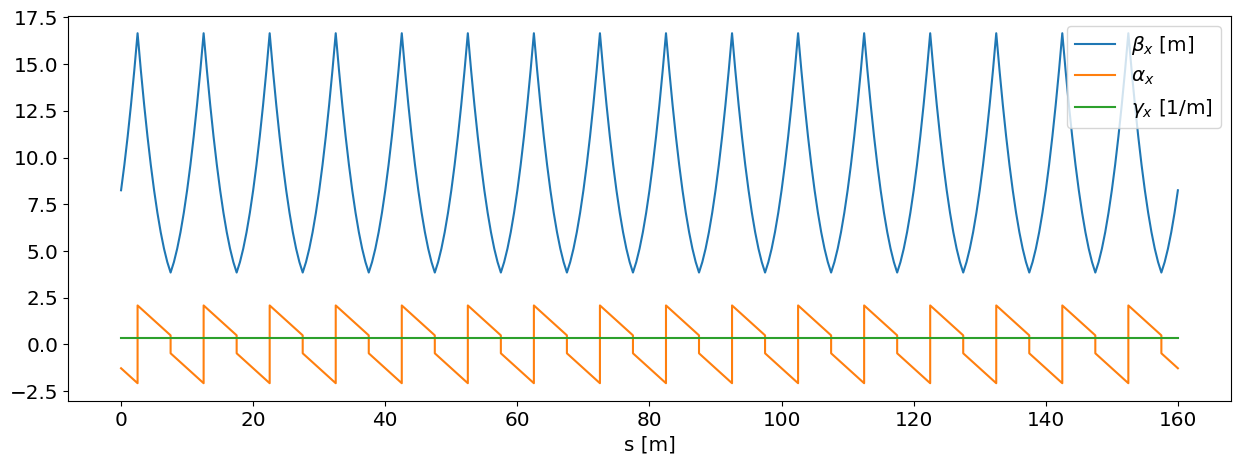

In [22]:
plt.plot(s,betas, label=r'$\beta_x$ [m]')
plt.plot(s,alphas, label=r'$\alpha_x$')
plt.plot(s,gammas, label=r'$\gamma_x$ [1/m]')
plt.legend()
plt.xlabel('s [m]')